#### 還抓得到耶
!wget https://www.dropbox.com/s/l2ul3upj7dkv4ou/synthetic-data.zip

In [1]:
# 這個程式注意要安裝
#有GPU的話，請使用以下指令安裝torch
#%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
#%pip install transformers
# 注意transformers版本要>=4.40.0，然後不要不小心更新到變成只有CPU的torch裝上去
#%pip install datasets
#%pip install sentencepiece
#%pip install accelerate
#%pip install evaluate
#%pip install jiwer

In [2]:
%reload_ext autoreload
%autoreload 2
from torch_snippets_local import stem, Glob, simple_show
import configparser, os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import pandas as pd
from PIL import Image

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
"Using Device:", device

('Using Device:', device(type='cuda'))

In [4]:
config = configparser.ConfigParser()
config.read('config.ini')
# Load parameters from config file
#root = '/Users/leonjye/Documents/MachineLearingData'
root = config.get('DEFAULT', 'root_dir')
image_folder = os.path.join(root, 'synthetic-data')
images = Glob(os.path.join(image_folder, '*.png'))

found 25132 files in /home/leonjye/Data/synthetic-data/*.png


In [5]:
fname2label = lambda fname: os.path.splitext(os.path.basename(fname))[0].split('@')[0]

In [ ]:
images_list = []
labels_list = []
# 打亂 images 的順序
import random
random.shuffle(images)
# 取前 5000 張圖片
for image in images:
  images_list.append(str(image).split('/')[-1])
  labels_list.append(fname2label(image))
data_limit = min(5000, len(images_list))  # 原本是5000喔
df = pd.DataFrame([images_list[:data_limit], labels_list[:data_limit]]).T
df.columns = ['file_name', 'text']
df.sample(10)

,file_name,text
2859,spring@ogzZJx.png,spring
422,image@J62mqn.png,image
3677,stop@edGH7w.png,stop
4673,drug@MdqEaj.png,drug
2807,value@Y5FH6C.png,value
2070,cup@X0EMHL.png,cup
2389,entire@TrR5k6.png,entire
912,it@eiPNXR.png,it
1777,more@9q3iXK.png,more
851,ever@SeN0fQ.png,ever


In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [8]:
class IAMDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # get file name + text
        file_name = self.df['file_name'][idx]
        text = self.df['text'][idx]
        # prepare image (i.e. resize + normalize)
        image = Image.open(os.path.join(self.root_dir, file_name)).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values
        # add labels (input_ids) by encoding the text
        labels = self.processor.tokenizer(text,
                                          padding="max_length",
                                          max_length=self.max_target_length).input_ids
        # important: make sure that PAD tokens are ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

In [9]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten", use_fast=True)

In [10]:
train_dataset = IAMDataset(root_dir=image_folder, df=train_df, processor=processor)
eval_dataset = IAMDataset(root_dir=image_folder, df=test_df, processor=processor)

In [ ]:
print("Number of training examples:", len(train_dataset))
print("Number of validation examples:", len(eval_dataset))

In [ ]:
encoding = train_dataset[0]
for k,v in encoding.items():
  print(k, v.shape)

In [ ]:
image = Image.open(os.path.join(image_folder, train_df['file_name'][0])).convert("RGB")
image

In [ ]:
labels = encoding['labels']
labels[labels == -100] = processor.tokenizer.pad_token_id
label_str = processor.decode(labels, skip_special_tokens=True)
'label_str =', label_str

In [ ]:
from transformers import VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-stage1 and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

In [ ]:
for name, param in model.named_parameters():
    param.requires_grad = True
    #print(name)
    # if name=='decoder.output_projection.weight':
    #     param.requires_grad = True


In [ ]:
# set special tokens used for creating the decoder_input_ids from the labels
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
# make sure vocab size is set correctly
model.config.vocab_size = model.config.decoder.vocab_size

# set beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

In [ ]:
from transformers import Seq2SeqTrainingArguments
print("Using Seq2SeqTrainingArguments...cude:", torch.cuda.is_available())
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="steps", # 這邊變成縮寫了，為啥 @@ 
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    fp16=torch.cuda.is_available(), # set to True if you have a GPU with compute capability >= 7.0
    output_dir="./",
    logging_steps=2,
    save_steps=1000,
    eval_steps=100,
    load_best_model_at_end=True,
    num_train_epochs = 10
)

原本的寫法

    import datasets
    cer_metric = datasets.load_metric("cer")

已經被棄用，改成以下的寫法
但要另外安裝

pip install evaluate

pip install jiwer

In [ ]:
import evaluate

cer_metric = evaluate.load("cer")

In [ ]:
def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer}

In [ ]:
from transformers import default_data_collator
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer
model = model.to(device)
# instantiate trainer
trainer = Seq2SeqTrainer(
    model=model,
    processing_class=processor,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=default_data_collator,
)
trainer.train()

In [ ]:
# save th model
model.save_pretrained("trocr-base-stage1-finetuned")
# save the processor
processor.save_pretrained("trocr-base-stage1-finetuned")

In [ ]:
# save the tokenizer
processor.tokenizer.save_pretrained("trocr-base-stage1-finetuned")
# save the config
model.config.save_pretrained("trocr-base-stage1-finetuned")

In [12]:
# load the model
model = VisionEncoderDecoderModel.from_pretrained("trocr-base-stage1-finetuned")
# load the processor
processor = TrOCRProcessor.from_pretrained("trocr-base-stage1-finetuned", use_fast=True)

Selected image file: eye@UrP60Q.png


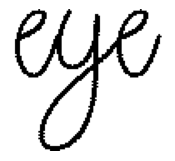

Generated IDs: tensor([[    0, 20668, 20668, 20668,     2]])
Predicted Text: eyeeyeeye


In [15]:
# Load and preprocess the image
# 從images中隨機挑選一張圖片
file_name = random.choice(images)
print("Selected image file:", os.path.basename(file_name))
image = Image.open(file_name).convert("RGB")
simple_show(image)
pixel_values = processor(image, return_tensors="pt").pixel_values

# Perform inference
model.eval()  # Set the model to evaluation mode
model.to('cpu') # Move model to the appropriate device
with torch.no_grad():
    generated_ids = model.generate(pixel_values)

# Move generated_ids to CPU if necessary
generated_ids = generated_ids.cpu()
print("Generated IDs:", generated_ids)

# Decode the generated ids to text
predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print("Predicted Text:", predicted_text)